In [1]:
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

In [ ]:
data_dir = "../data/faces/lfw_funneled" 
batch_size = 64
image_size = 64
latent_dim = 256
epochs = 50
lr = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Загружено {len(dataset)} изображений")

Загружено 13233 изображений


In [4]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),  # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),  # 8 -> 4
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 4 -> 8
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),   # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),    # 16 -> 32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 32 -> 64
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 4, 4)
        return self.deconv(x)


In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    
    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

In [7]:
model = VAE(latent_dim).to(device)
optimizer = optim.AdamW(model.parameters(), lr=lr)
loss_history = []

def loss_function(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.1 * kld 

os.makedirs("results", exist_ok=True)

In [8]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(imgs)
        loss = loss_function(recon, imgs, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader.dataset)
    loss_history.append(avg_loss)
    print(f"Эпоха [{epoch+1}/{epochs}], Потеря: {avg_loss:.4f}")

    # Сохраняем реконструкции
    model.eval()
    with torch.no_grad():
        sample = next(iter(dataloader))[0][:8].to(device)
        recon, _, _ = model(sample)
        vutils.save_image(
            torch.cat([sample, recon], dim=0),
            f"results/reconstruction_epoch_{epoch+1}.png",
            nrow=8, normalize=True
        )

Эпоха [1/50], Потеря: 7292.9150
Эпоха [2/50], Потеря: 6635.0204
Эпоха [3/50], Потеря: 6495.6861
Эпоха [4/50], Потеря: 6390.0267
Эпоха [5/50], Потеря: 6337.2058
Эпоха [6/50], Потеря: 6300.5901
Эпоха [7/50], Потеря: 6274.5799
Эпоха [8/50], Потеря: 6255.0245
Эпоха [9/50], Потеря: 6239.1943
Эпоха [10/50], Потеря: 6223.7114
Эпоха [11/50], Потеря: 6211.5558
Эпоха [12/50], Потеря: 6201.3125
Эпоха [13/50], Потеря: 6191.6084
Эпоха [14/50], Потеря: 6183.7709
Эпоха [15/50], Потеря: 6176.5762
Эпоха [16/50], Потеря: 6170.0808
Эпоха [17/50], Потеря: 6164.3712
Эпоха [18/50], Потеря: 6159.1388
Эпоха [19/50], Потеря: 6153.5544
Эпоха [20/50], Потеря: 6147.1787
Эпоха [21/50], Потеря: 6142.1277
Эпоха [22/50], Потеря: 6137.2860
Эпоха [23/50], Потеря: 6133.2640
Эпоха [24/50], Потеря: 6129.6390
Эпоха [25/50], Потеря: 6126.1921
Эпоха [26/50], Потеря: 6120.2183
Эпоха [27/50], Потеря: 6116.3361
Эпоха [28/50], Потеря: 6117.5009
Эпоха [29/50], Потеря: 6110.3647
Эпоха [30/50], Потеря: 6109.1281
Эпоха [31/50], Поте

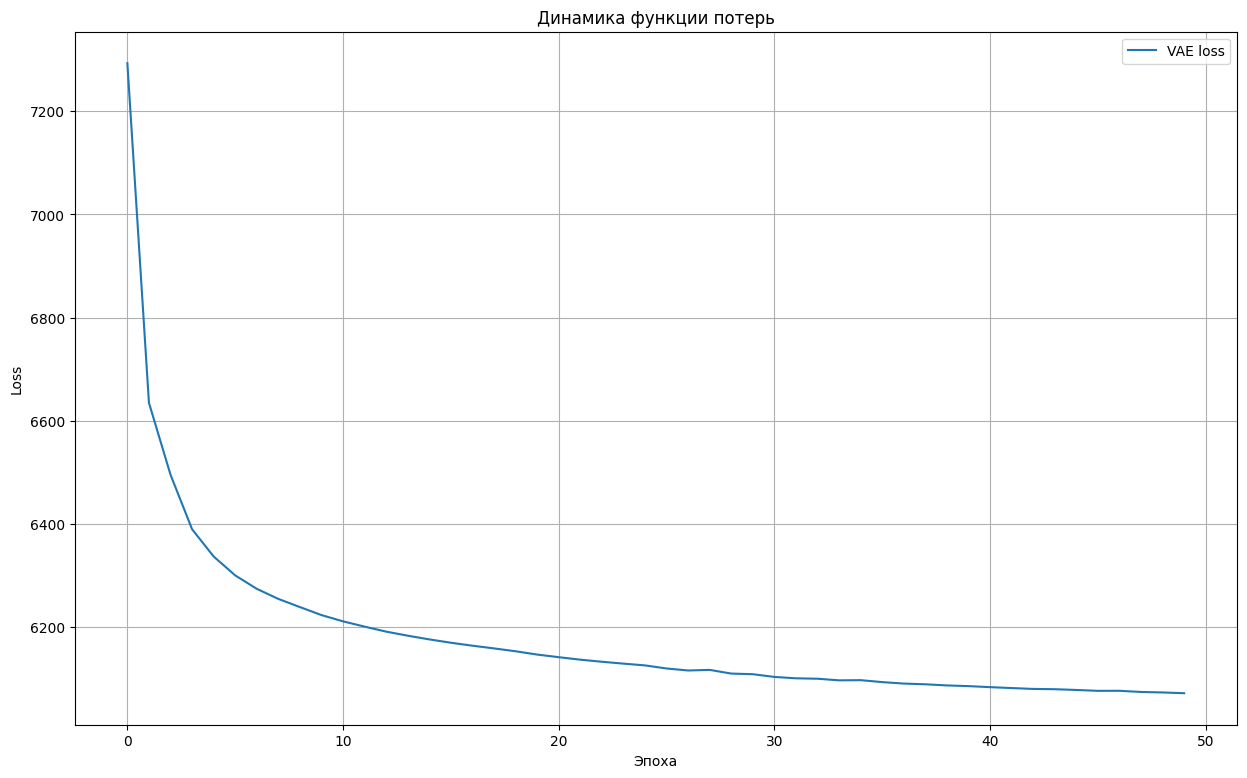

In [9]:
plt.figure(figsize=(15,9))
plt.plot(loss_history, label="VAE loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Динамика функции потерь")
plt.legend()
plt.grid()
plt.show()

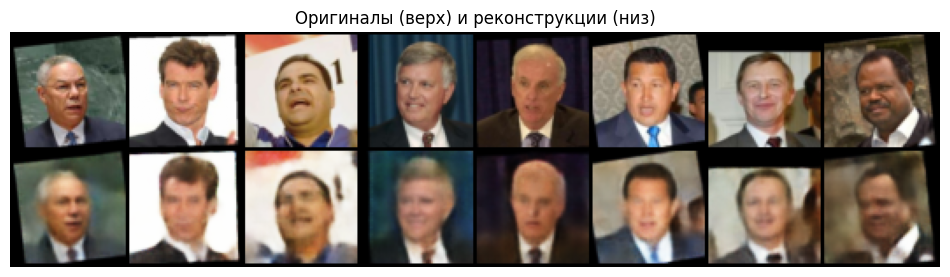

In [10]:
model.eval()
with torch.no_grad():
    data_iter = iter(dataloader)
    imgs, _ = next(data_iter)
    imgs = imgs.to(device)

    recon_imgs, _, _ = model(imgs)
    comparison = torch.cat([imgs[:8], recon_imgs[:8]])  # верх — оригиналы, низ — реконструкции

# Отображение
plt.figure(figsize=(12, 6))
plt.imshow(np.transpose(vutils.make_grid(comparison.cpu(), nrow=8, normalize=True), (1, 2, 0)))
plt.axis('off')
plt.title("Оригиналы (верх) и реконструкции (низ)")
plt.show()

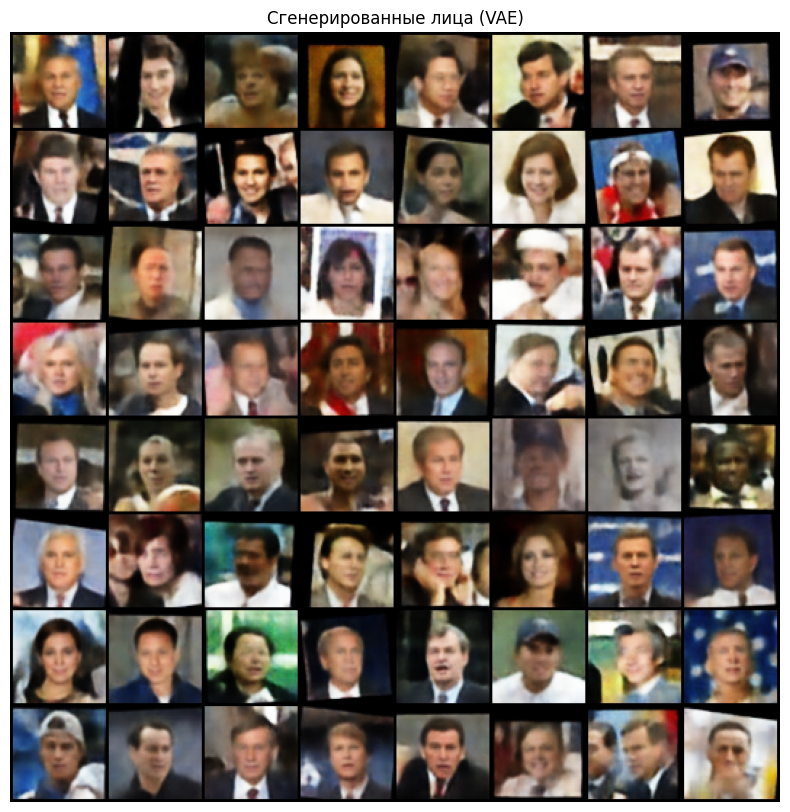

In [12]:
model.eval()
beta = 0.1  
with torch.no_grad():
    imgs, _ = next(iter(dataloader))
    imgs = imgs.to(device)

    mu, logvar = model.encode(imgs)
    eps = 0.1 * torch.randn_like(mu)  # маленький шум
    z = mu + eps
    generated = model.decoder(z).cpu()
    vutils.save_image(generated, "results/generated_faces.png", nrow=4, normalize=True)

plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(vutils.make_grid(generated, nrow=8, normalize=True), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные лица (VAE)")
plt.show()